 TLS Traffic Analysis System with Autoencoders
--------------------------------------------
This module implements a system for analyzing TLS traffic patterns using autoencoders
to detect anomalies. It processes TLS records from JSON files, extracts relevant features,
and uses an autoencoder neural network to learn normal patterns.

The system can then evaluate new datasets against the learned patterns to identify
potential anomalies based on reconstruction error.

> This notebook represents the original implementation, without any modifications.

# Install Python libraries

Install the following Python libraries if not already available in the current kernel.

In [1]:
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn

# Dataset Preparation

The data are read from all samples in the given folder (desktop applications). From the source JSON we extract only the following (numerical) features:

* Flow Data: A subset of columns that contain numerical flow metrics ('BytesOut', 'PacketsOut', 'BytesIn', 'PacketsIn', 'Duration') is extracted from the DataFrame. These values are converted to a NumPy array of type float32.
* TLS Records size sequence: The 'RecordSequence' column, which holds sequences (arrays) of integers is taken and the array is padded or truncated so that its length is exactly RECORD_SEQUENCE_SIZE (20). These values are converted to a NumPy array of type float32.

The processed numerical flow data and the padded record sequences are concatenated horizontally (column-wise) such that each row has exactly 25 columns. Any NaN values in the concatenated dataset are replaced with 0.

For each column in the dataset, the minimum and maximum values are computed. A min-max normalization is then applied column-wise. This rescales every value so that each feature (column) lies in the range [0,1].

`normal_df` is prepared and can be used for the autoencoder training.

In [2]:
#
# This is just ot make the visualization nicer...
#
import math

def is_composite(x):
    """Return True if x is composite (not prime) and x >= 4; otherwise False."""
    if x < 4:
        return False  # 2 and 3 are prime; 1 is neither prime nor composite
    for i in range(2, int(math.sqrt(x)) + 1):
        if x % i == 0:
            return True
    return False

def find_nearest_composites(n):
    """Return the composite numbers greater than n."""
    candidates = []
    for i in range(n, int(n * 3 / 2)):
        if is_composite(i):
            candidates.append(i)
    return candidates

def greatest_divisor_pair(x):
    """
    Return the pair of divisors (d, x//d) for composite x such that
    d is the greatest divisor not exceeding sqrt(x). This pair is closest to each other.
    """
    d = int(math.sqrt(x))
    while d > 1:
        if x % d == 0:
            return (d, x // d)
        d -= 1
    return (1, x)

def get_padding_and_dim(x):
    dif = x
    val_x = x
    val_d1 = 0
    val_d2 = 0
    for nearest in find_nearest_composites(x):
        d1, d2 = greatest_divisor_pair(nearest)  
        if (math.fabs(d1-d2) > dif):
            return (val_x, val_d1, val_d2)
        else:
            val_x = nearest
            val_d1 = d1
            val_d2 = d2
            dif = math.fabs(d1-d2) 

In [3]:
import json
import glob
import pandas as pd
import numpy as np
from array import array
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

RECORD_SEQUENCE_SIZE=20
tls_columns_names = np.array([f"tls.rec.{i}" for i in range(RECORD_SEQUENCE_SIZE)])

# Resize row in the array
def resize_row(row, maxlen, pad_value=0):
    current_length = len(row)
    if current_length < maxlen:
        # Calculate the amount of padding needed
        pad_width = maxlen - current_length
        # Pad at the end (you can also pad at the beginning or both sides)
        row = np.pad(row, pad_width=(0, pad_width), mode='constant', constant_values=pad_value)
    else:
        # If the row is longer than the target length, slice it
        row = row[:maxlen]
    return row
# Resize the matrix by padding or removing columns
def pad_sequences(rows, maxlen, pad_value=0):
    resized_rows = [resize_row(row, maxlen) for row in rows]
    return resized_rows

# Loads data from the specified collection of json files. It provides raw data.
def load_json_files(json_files):
    all_data = []
    # Open the file and read each line
    for filename in json_files:
        with open(filename, "r") as file:
            # Use a list comprehension to load each line as a JSON object
            data = [json.loads(line.strip()) for line in file]
            for item in data: all_data.append(item)
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_data)
    return df

# Extracts features from raw dataset. This will provide suitable output to the preprocessing pipeline.
# Flow related columns: 'BytesOut', 'PacketsOut', 'BytesIn', 'PacketsIn', 'Duration'
# TLS handshake columns: 'TlsClientVersion','TlsServerVersion','TlsServerCipherSuite'
# TLS record sizes: 'RecordSequence' mapped as 'TlsRecord_X'
#
# The output is a DataFrame with the above specified columns. This dataframe can beused as the input to next
# processing block (preprocessor).
#
def extract_features(df):
    # Flow data
    flow_data = df[['bs', 'ps', 'br', 'pr', 'td']].astype(float)
    # TLS handshake data
    tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str) 
    # TLS records 
    records_data = pd.DataFrame( pad_sequences(df['tls.rec'].values, maxlen=RECORD_SEQUENCE_SIZE), columns=tls_columns_names)
    dataset = pd.concat([flow_data, tls_data, records_data], axis=1).fillna(0)
    return dataset
#
# Fits the preprocessor that contains scalers for numerical features and OneHotEncoder for categorical data.
# The result is the Pipeline that can be used for further data processing before they are fed in the Autoencoder.
# 
def fit_preprocessor(df):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_flow', MinMaxScaler(), ['bs', 'ps', 'br', 'pr', 'td']),
            ('num_tls', MinMaxScaler(), tls_columns_names),
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['tls.cver','tls.sver','tls.scs'])
        ])
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
    pipeline.fit(df)
    return pipeline


# -------------------------------------------------
# Load normal data and prepare them for Autoencoder
# Normal data are for now represented as the desktop application communication.
#
raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
print(f'dataset shape={raw_df.shape}')
input_df = extract_features(raw_df)

pipeline = fit_preprocessor(input_df)
normal_df = pipeline.transform(input_df)

print('Normalized row of data:')
print(normal_df[0])

print(f'dataset shape={normal_df.shape}')

row_len = normal_df.shape[1]
(newrow_len,IMAGE_DIM_X,IMAGE_DIM_Y) = get_padding_and_dim(row_len)
IMAGE_PAD= newrow_len - row_len
print(f"visualization adjustement: {row_len} -> {newrow_len} (+ {IMAGE_PAD}) [{IMAGE_DIM_X} x {IMAGE_DIM_Y}]")

def make_image_from_sample(sample):
    return np.pad(sample, pad_width=(0,IMAGE_PAD), mode='constant', constant_values=0).reshape(IMAGE_DIM_X, IMAGE_DIM_Y)



dataset shape=(14962, 28)
Normalized row of data:
[2.17753132e-03 2.21631206e-03 9.79934060e-05 8.92359175e-04
 6.24198375e-03 8.35066163e-01 9.25056978e-03 1.61063331e-02
 4.89771620e-01 9.18864858e-02 4.91283677e-02 1.96893508e-01
 5.67007398e-02 3.53978244e-01 2.29417032e-01 3.23067383e-01
 3.14913671e-01 2.98925203e-01 2.89292228e-01 5.08128222e-01
 5.07518224e-01 5.00594748e-01 4.98520755e-01 4.99557752e-01
 4.99557752e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
dataset shape=(14962, 35)
visualization adjustement: 35 -> 36 (+ 1) [6 x 6]


# Autoencoder Training

The autoencoder is trained on `normal_df`. The data are split into training (80%) and testing (20%) parts. The size of laten space is set to `LATENT_SPACE_SIZE`.

The results are visualzied for the 10 selected sample. 

Read more: https://www.tensorflow.org/tutorials/generative/autoencoder

train shape=(11969, 35)
test shape=(2993, 35)
Epoch 1/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 761us/step - loss: 0.5336 - val_loss: 0.3737
Epoch 2/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - loss: 0.3668 - val_loss: 0.3364
Epoch 3/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 658us/step - loss: 0.3320 - val_loss: 0.3214
Epoch 4/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - loss: 0.3210 - val_loss: 0.3166
Epoch 5/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step - loss: 0.3164 - val_loss: 0.3138
Epoch 6/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - loss: 0.3144 - val_loss: 0.3122
Epoch 7/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - loss: 0.3132 - val_loss: 0.3110
Epoch 8/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - loss: 0.3117 - val_loss: 0.3101
Epoch 9/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step - loss: 0.3110 - val_loss: 0.3093
Epoch 10/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 724us/step - loss: 0.3099 - val_loss: 0.3086
Epoch 11/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - loss: 0.3089 - v

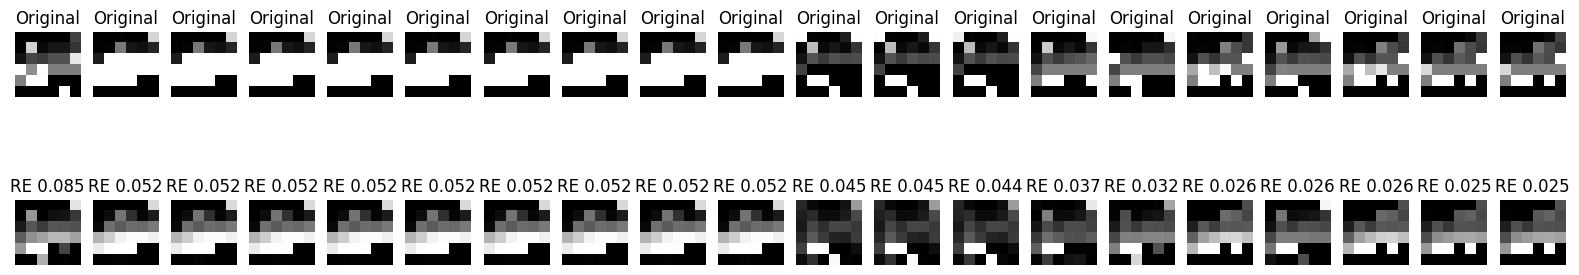

In [4]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
LATENT_SPACE_SIZE=6

# 1. Split data to traingin and testing
x_train, x_test = train_test_split(normal_df, test_size=0.2)
print(f'train shape={x_train.shape}')
print(f'test shape={x_test.shape}')

# 2. Define dimensions and architecture
input_dim = x_train.shape[1]
encoding_dim = LATENT_SPACE_SIZE  # Size of the latent space

# Input placeholder
input_img = Input(shape=(input_dim,))

# Encoder layers
encoded = Dense(encoding_dim, activation='relu')(input_img)

# Decoder layers
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Encoder model for later use
encoder = Model(input_img, encoded)

# Decoder model setup
encoded_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

# 3. Compile and train the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,
                epochs=50,                      # use some more reasonable number here (>50)
                batch_size=16,
                shuffle=True,
                validation_data=(x_test, x_test))

# 4. Visualize the reconstructed images
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

# Assuming x_test contains the original test data
# and decoded_imgs are the autoencoder's reconstructed outputs
reconstruction_errors = np.mean(np.square(x_test - decoded_imgs), axis=1)

# Average reconstruction error across all samples
avg_error = np.mean(reconstruction_errors)
max_error = np.max(reconstruction_errors)
min_error = np.min(reconstruction_errors)
print(f"Reconstruction error for each sample {reconstruction_errors}")
print(f"Average={avg_error}, Max={max_error}, Min={min_error} reconstruction errors.")

# Get indices that would sort the array in ascending order
worst20 = np.argsort(reconstruction_errors)[-20:][::-1]

n = 20  # Number of digits to display
i = 0

print("Worst reconstructed:")
plt.figure(figsize=(20, 4))
for j in worst20:
    reconstruction_error = reconstruction_errors[j]
    original = x_test[j]
    original = make_image_from_sample(original) 
    reconstructed = decoded_imgs[j]
    reconstructed = make_image_from_sample(reconstructed) 
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"RE {reconstruction_error:.3f}")
    plt.axis('off')
    i+=1
plt.show()


## Reconstruction

In this section, threshold tuning was performed to optimize the anomaly detection process. Metrics such as recall, precision, and accuracy were observed across different threshold values to identify the optimal threshold for anomaly classification. The recall metric was particularly emphasized to ensure the detection of as many anomalies as possible.

For further details and reference, the implementation was inspired by the following repository:  
[Anomaly Detection with Autoencoders](https://github.com/AarnoStormborn/anomaly-detection-with-autoencoder/blob/main/anomaly-detection-with-autoencoders.ipynb)



In [5]:
# load the malicious dataset
abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.adware.tls/*.json"))
input_abnormal_df = extract_features(abnormal_raw_df)
    
abnormal_df = pipeline.transform(input_abnormal_df)

# calculate reconstruction errors for abnormal data
encoded_abnormal = encoder.predict(abnormal_df)
decoded_abnormal = decoder.predict(encoded_abnormal)
errors_abnormal = np.mean(np.square(abnormal_df - decoded_abnormal), axis=1)

# create a DataFrame for the reconstruction errors
recons_abnormal_df = pd.DataFrame({
    'error': errors_abnormal,
    'y_true': np.ones(len(errors_abnormal), dtype=int)
})

# let normal_df be the normal data
recons_normal_df = pd.DataFrame({
    'error': reconstruction_errors,
    'y_true': np.zeros(len(reconstruction_errors), dtype=int)  
})

recons_df = pd.concat([recons_normal_df, recons_abnormal_df], ignore_index=True)
recons_df.head()

223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step


,error,y_true
0,0.000463,0
1,0.002270,0
2,0.000143,0
3,0.000941,0
4,0.000358,0


In [10]:
from sklearn.metrics import classification_report
def thresholdTuning(df, iterations):
    
    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }
    
    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = df['error'] > thresh_value
        cr = classification_report(df['y_true'], preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']
        
        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)
        
        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")
        
    return pd.DataFrame(thresh_df)
        
thresh_df = thresholdTuning(recons_df, 100)

Threshold: 0.0001	Accuracy: 0.704		Precision: 0.852	Recall Score: 0.500
Threshold: 0.0001	Accuracy: 0.714		Precision: 0.856	Recall Score: 0.517
Threshold: 0.0001	Accuracy: 0.724		Precision: 0.859	Recall Score: 0.534
Threshold: 0.0002	Accuracy: 0.734		Precision: 0.863	Recall Score: 0.551
Threshold: 0.0002	Accuracy: 0.744		Precision: 0.867	Recall Score: 0.568
Threshold: 0.0002	Accuracy: 0.754		Precision: 0.871	Recall Score: 0.585
Threshold: 0.0003	Accuracy: 0.764		Precision: 0.875	Recall Score: 0.601
Threshold: 0.0003	Accuracy: 0.774		Precision: 0.878	Recall Score: 0.618
Threshold: 0.0003	Accuracy: 0.784		Precision: 0.882	Recall Score: 0.635
Threshold: 0.0004	Accuracy: 0.794		Precision: 0.885	Recall Score: 0.651
Threshold: 0.0004	Accuracy: 0.794		Precision: 0.863	Recall Score: 0.657
Threshold: 0.0004	Accuracy: 0.794		Precision: 0.845	Recall Score: 0.662
Threshold: 0.0004	Accuracy: 0.786		Precision: 0.810	Recall Score: 0.657
Threshold: 0.0005	Accuracy: 0.781		Precision: 0.787	Recall Score

In [11]:
threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold with Maximum Recall: 0.018479


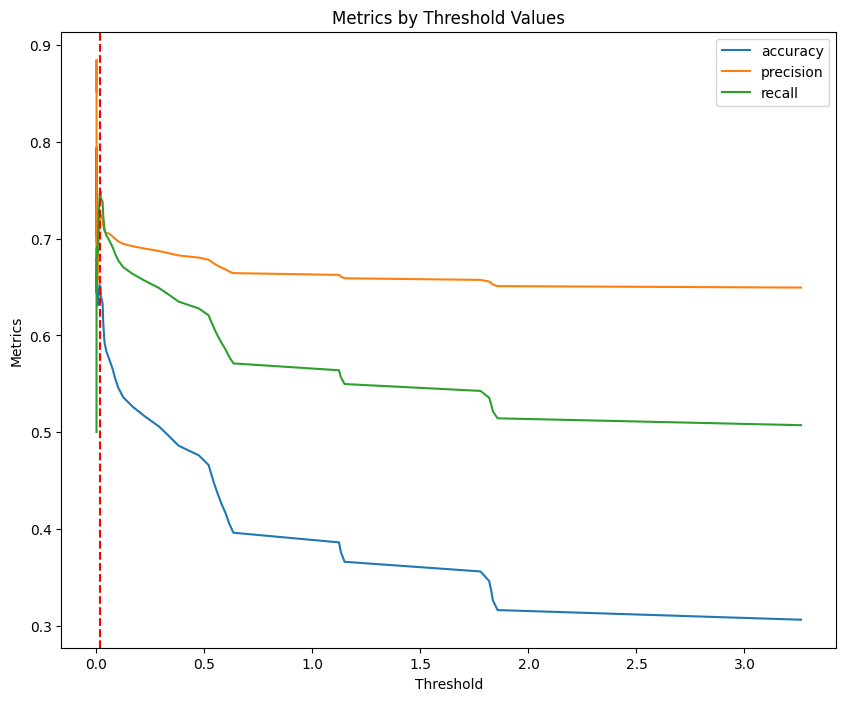

In [12]:
plt.figure(figsize=(10,8))
plt.plot(thresh_df['threshold'], thresh_df['accuracy'], label='accuracy')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

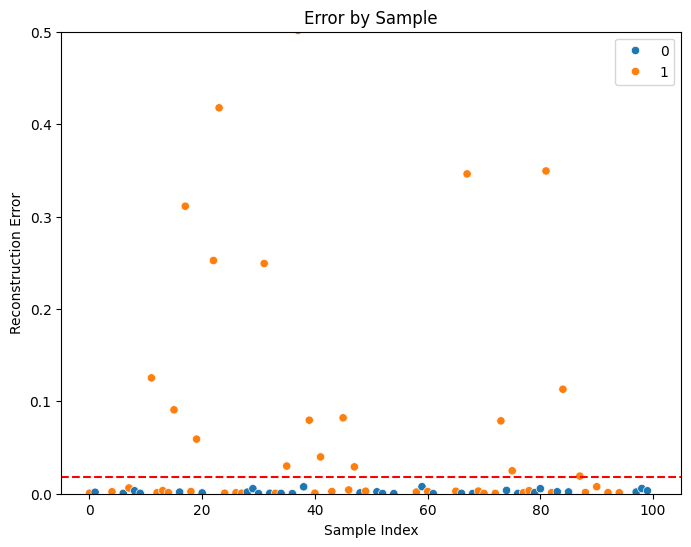

In [13]:
import seaborn as sns
temp = recons_df.sample(frac=0.01, random_state=42).reset_index(drop=True)

plt.figure(figsize=(8,6))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.ylim(0, 0.5)  
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Error by Sample')
plt.legend()
plt.show()


# Test with unknown data

Next, we load ISCX data set and use previously trained Autoencoder. The reconstruction error shuld be significantly higher.

In [14]:
def test_dataset(json_files):
    raw_test_df = load_json_files(json_files)
    print(f'raw dataset shape={raw_test_df.shape}')
    input_test_df = extract_features(raw_test_df)
    test_df = pipeline.transform(input_test_df)

    print('Normalized row of data:')
    print(test_df[0])
    print(f'dataset shape={test_df.shape}')

    encoded_test = encoder.predict(test_df)
    decoded_test = decoder.predict(encoded_test)

    # Assuming x_test contains the original test data
    # and decoded_imgs are the autoencoder's reconstructed outputs
    test_reconstruction_errors = np.mean(np.square(test_df - decoded_test), axis=1)

    # Get indices that would sort the array in ascending order
    worst10 = np.argsort(test_reconstruction_errors)[-10:][::-1]

    # Average reconstruction error across all samples
    test_avg_error = np.mean(test_reconstruction_errors)
    print("Reconstruction error for each sample:", test_reconstruction_errors)
    print("Average reconstruction error:", test_avg_error)

    print("Worst reconstructed:")
    n = 10  # Number of digits to display
    i = 0
    plt.figure(figsize=(20, 4))
    for j in worst10:
        rec_error = test_reconstruction_errors[j]
        original = test_df[j]
        original = make_image_from_sample(original)  
        reconstructed = decoded_test[j]
        reconstructed = make_image_from_sample(reconstructed)
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"RE {rec_error:.3f}")
        plt.axis('off')
        i+=1
    plt.show()

raw dataset shape=(1112, 28)
Normalized row of data:
[3.64658354e-03 4.43262411e-03 1.54566237e-05 8.92359175e-04
 7.37067123e-02 8.35066163e-01 3.75385440e-03 1.61063331e-02
 4.43770971e-03 9.18864858e-02 8.55784469e-02 2.15107833e-01
 7.09888745e-02 3.26178469e-01 2.23101937e-01 3.23811492e-01
 3.13245475e-01 2.83044527e-01 2.67627564e-01 5.01540245e-01
 4.98642755e-01 5.01570745e-01 4.87937292e-01 4.98734254e-01
 5.01875743e-01 1.00000000e+00 1.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.00000000e+00 0.00000000e+00 0.00000000e+00]
dataset shape=(1112, 35)
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step
Reconstruction error for each sample: [0.00264484 0.00263506 0.00264226 ... 0.0094689  0.00849193 2.42944052]
Average reconstruction error: 0.2917718181791724
Worst reconstructed:


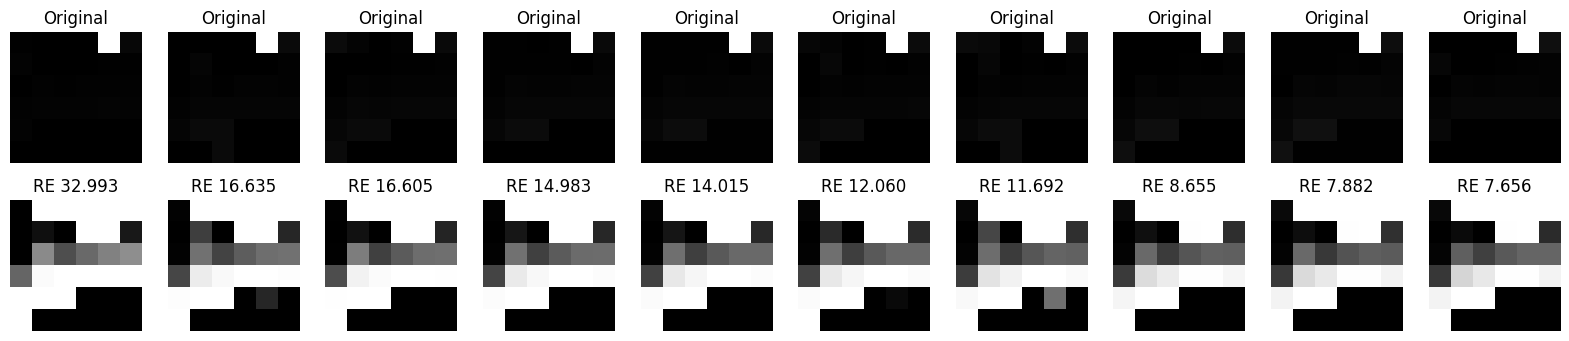

In [15]:
test_dataset(json_files=glob.glob("../datasets/iscx.tls/*.json"))

raw dataset shape=(5616, 28)
Normalized row of data:
[4.48008835e-04 4.43262411e-04 3.72917513e-05 2.23089794e-04
 1.65312812e-03 8.35066163e-01 9.25056978e-03 1.61063331e-02
 2.33466825e-01 9.18864858e-02 6.49762282e-02 2.58129400e-01
 7.65798837e-02 3.16425624e-01 2.26730760e-01 3.21992559e-01
 3.15997998e-01 2.80193025e-01 2.70074292e-01 4.99557752e-01
 4.99557752e-01 4.99557752e-01 4.99557752e-01 4.99557752e-01
 4.99557752e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
dataset shape=(5616, 35)
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Reconstruction error for each sample: [0.00031776 0.00017084 0.00170359 ... 0.00055648 0.000765   0.00031089]
Average reconstruction error: 0.004117693151378358
Worst reconstructed:


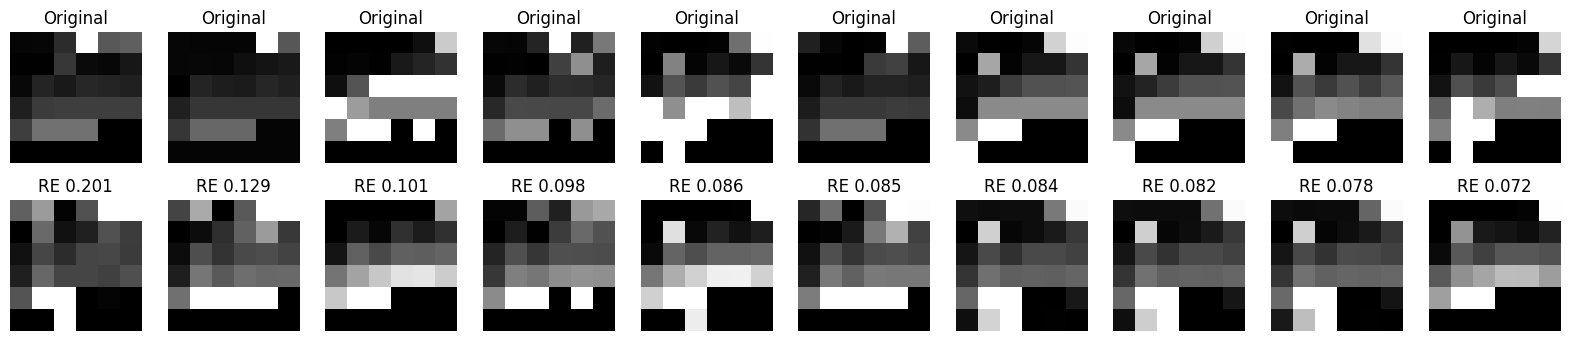

In [ ]:
test_dataset(glob.glob("../datasets/mobile.tls/*.json"))

raw dataset shape=(15047, 28)
Normalized row of data:
[3.89663498e-03 1.32978723e-03 6.56112501e-05 6.69269381e-04
 8.56890409e-01 7.92533081e-01 9.25056978e-03 1.61063331e-02
 4.65418335e-03 4.19427428e-01 5.94294770e-01 2.12537714e-01
 7.33043429e-02 3.14216647e-01 1.99868043e-01 3.25051674e-01
 3.19084160e-01 3.12349199e-01 2.44717292e-01 5.21914173e-01
 4.99557752e-01 4.99557752e-01 4.99557752e-01 4.99557752e-01
 4.99557752e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
dataset shape=(15047, 35)
471/471 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
471/471 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Reconstruction error for each sample: [0.00194622 0.00084377 0.00083664 ... 0.00733983 0.00708416 0.00728634]
Average reconstruction error: 0.002957106585072028
Worst reconstructed:


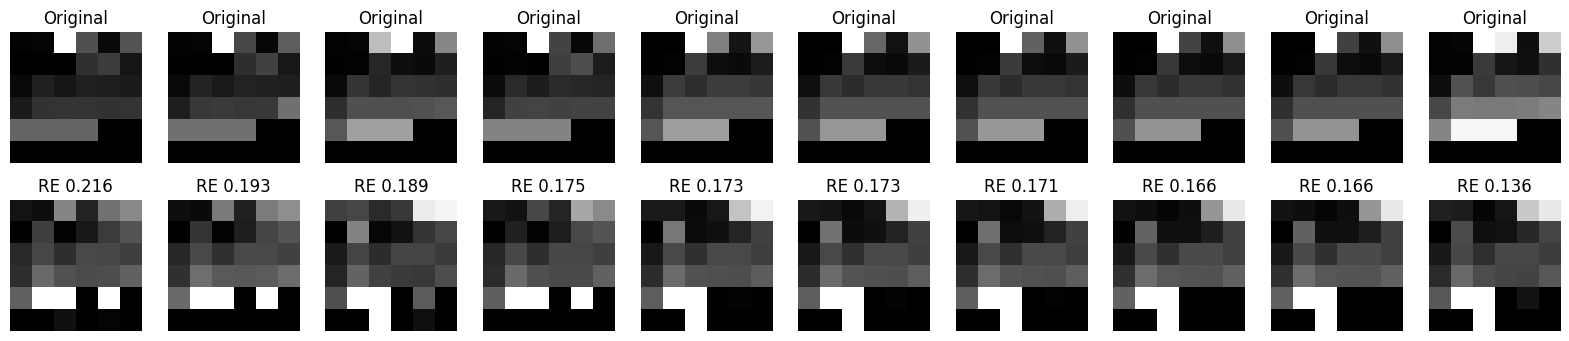

In [ ]:
test_dataset(glob.glob("../datasets/windows.tls/*.json"))

raw dataset shape=(31179, 28)
Normalized row of data:
[3.15663900e-02 5.76241135e-03 9.71861680e-05 1.22699387e-03
 8.61268348e+00 9.85822306e-01 5.63078161e-03 5.12275215e-01
 3.61510986e-02 9.25115639e-02 3.80348653e-02 2.06503520e-01
 7.11018241e-02 3.16467303e-01 2.28615863e-01 2.62257131e-01
 3.34306448e-01 2.25926738e-01 2.94497086e-01 4.49385427e-01
 5.16424193e-01 4.61951383e-01 5.13313203e-01 4.67380364e-01
 5.12306707e-01 1.00000000e+00 1.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.00000000e+00 0.00000000e+00 0.00000000e+00]
dataset shape=(31179, 35)
975/975 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
975/975 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Reconstruction error for each sample: [1.81805126e+00 1.79485393e+00 1.80578953e+00 ... 1.79305058e+00
 5.59980960e-04 1.10622397e+00]
Average reconstruction error: 703.6346457120993
Worst reconstructed:


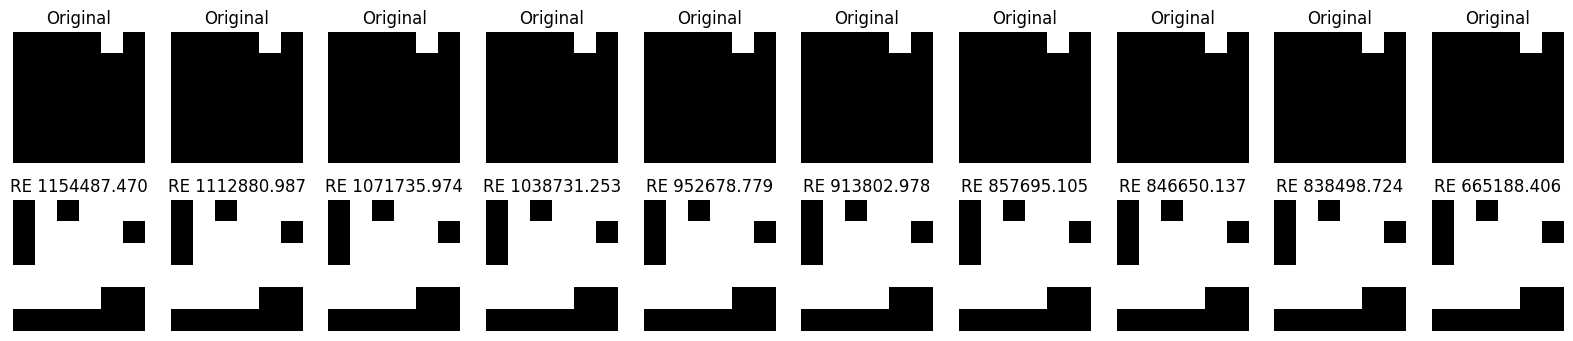

In [ ]:
test_dataset(glob.glob("../datasets/cic-aa.normal.tls/*.json"))

raw dataset shape=(462, 28)
Normalized row of data:
[1.42477228e-03 1.32978723e-03 4.42525253e-05 5.57724484e-04
 3.38053299e+00 9.75897921e-01 1.34066229e-03 6.00625489e-01
 1.61272865e-02 9.25115639e-02 3.80348653e-02 2.06503520e-01
 7.11018241e-02 3.24344601e-01 2.26777888e-01 3.23646135e-01
 3.00400367e-01 2.81289757e-01 2.74878776e-01 5.03217739e-01
 4.96660262e-01 4.99557752e-01 4.99557752e-01 4.99557752e-01
 4.99557752e-01 1.00000000e+00 1.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]
dataset shape=(462, 35)
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Reconstruction error for each sample: [2.48306718e-01 5.54251631e-04 6.40960495e-02 7.16641168e-04
 6.88980093e-04 1.79564612e+00 6.50058859e-02 6.50063637e-02
 4.24667233e-02 6.34765389e-04 5.24401445e-03 5.25081596e-03
 7.24943298e-04 6.46239726e-03 6.15738574e-04 2.05284416e-01
 6.46691121e-03 6.28385307e

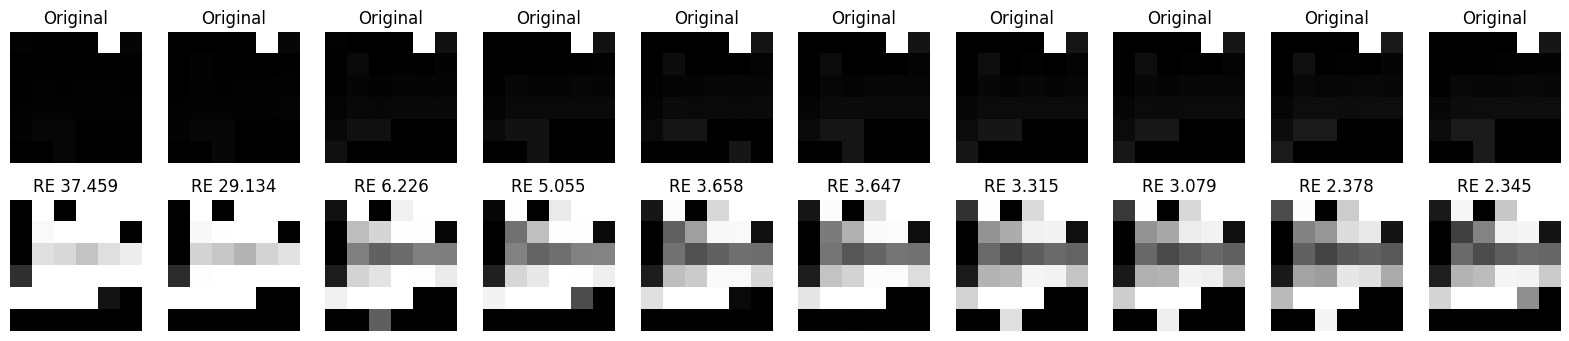

In [ ]:
test_dataset(glob.glob("../datasets/cic-aa.malware.tls/*.json"))

raw dataset shape=(7122, 28)
Normalized row of data:
[2.00197436e-02 4.87588652e-03 6.98194747e-05 8.92359175e-04
 8.57631466e+00 9.85822306e-01 5.63078161e-03 5.12275215e-01
 3.61510986e-02 9.25115639e-02 3.80348653e-02 2.06503520e-01
 7.11018241e-02 3.16467303e-01 2.28615863e-01 2.90367921e-01
 3.32638252e-01 2.37332748e-01 2.87646248e-01 4.67044865e-01
 5.12276207e-01 3.76307683e-01 5.14045201e-01 4.56491902e-01
 5.12672706e-01 1.00000000e+00 1.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.00000000e+00 0.00000000e+00 0.00000000e+00]
dataset shape=(7122, 35)
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Reconstruction error for each sample: [1.80244450e+00 1.80849805e+00 7.01715693e-04 ... 6.11977210e-04
 1.79960264e+00 1.79307124e+00]
Average reconstruction error: 1.349218212452897
Worst reconstructed:


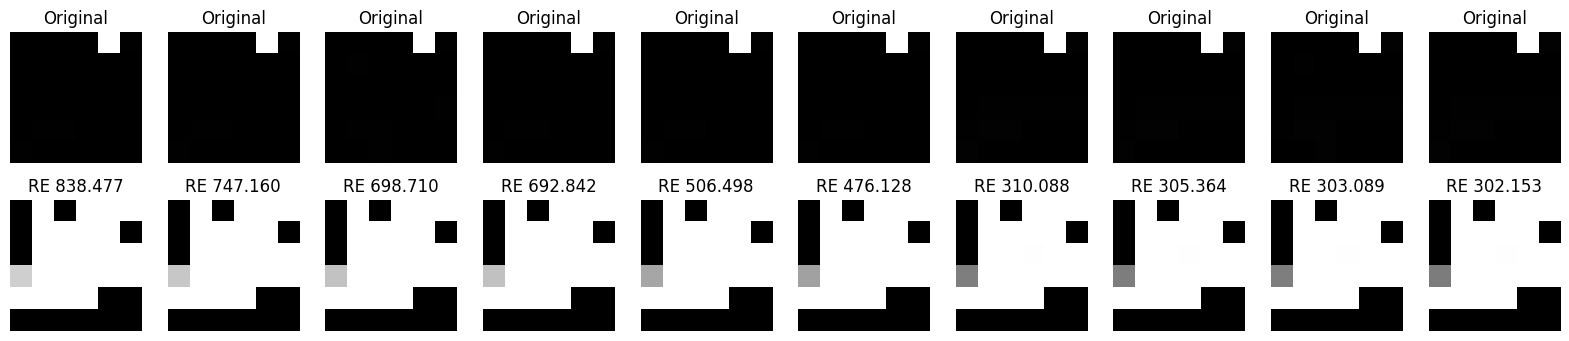

In [ ]:
test_dataset(glob.glob("../datasets/cic-aa.adware.tls/*.json"))